# 1 - Reinforcement Learning with Grid World

## Problem Definition

A robotics research team wants to train an intelligent agent to navigate a grid- based environment and reach a target location while avoiding obstacles. The environment consists of states represented by grid cells, actions representing movements (up, down, left, right), and rewards assigned based on successful navigation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class GridWorld:
    def __init__(
        self,
        size=6,
        start=(0, 0),
        goals=None,
        traps=None,
        obstacles=None,
        stochastic=False,
        slip_prob=0.2,
    ):
        self.size = size
        self.start_pos = start

        # Primary and secondary goals: {coordinate: reward}
        self.goals = goals if goals is not None else {(5, 5): 20, (0, 5): 5}

        # Traps / penalty states (terminal)
        self.traps = traps if traps is not None else [(2, 3), (4, 1)]

        # Obstacles / walls (non-terminal impassable blocks)
        self.obstacles = obstacles if obstacles is not None else [(1, 1), (3, 3)]

        # Environment dynamics
        self.stochastic = stochastic
        self.slip_prob = slip_prob

        # Action vectors: 0: Up, 1: Down, 2: Left, 3: Right
        self.action_moves = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
        self.reset()

    def reset(self):
        self.agent_pos = self.start_pos
        return self.agent_pos

    def _resolve_action(self, action):
        if not self.stochastic or np.random.rand() >= self.slip_prob:
            return action
        # Random slip to an alternate direction
        possible_slips = [a for a in range(4) if a != action]
        return np.random.choice(possible_slips)

    def step(self, action):
        actual_action = self._resolve_action(action)
        move = self.action_moves[actual_action]

        next_r = self.agent_pos[0] + move[0]
        next_c = self.agent_pos[1] + move[1]

        # Boundary collision check
        if not (0 <= next_r < self.size and 0 <= next_c < self.size):
            return self.agent_pos, -1, False

        # Obstacle collision check
        if (next_r, next_c) in self.obstacles:
            return self.agent_pos, -2, False

        self.agent_pos = (next_r, next_c)

        # Terminal trap check
        if self.agent_pos in self.traps:
            return self.agent_pos, -15, True

        # Terminal goal check
        if self.agent_pos in self.goals:
            return self.agent_pos, self.goals[self.agent_pos], True

        # Default step penalty to encourage optimal path
        return self.agent_pos, -1, False

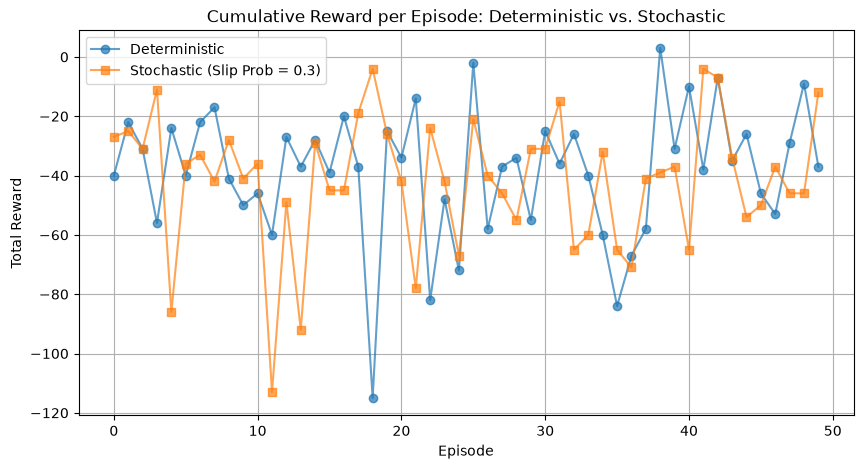

In [3]:
def run_simulation(env, episodes=50, max_steps=100):
    rewards_per_episode = []
    for _ in range(episodes):
        state = env.reset()
        total_reward = 0
        for _ in range(max_steps):
            # Random exploration policy
            action = np.random.choice(4)
            next_state, reward, done = env.step(action)
            total_reward += reward
            if done:
                break
        rewards_per_episode.append(total_reward)
    return rewards_per_episode


# Compare Deterministic vs. Stochastic Environments
env_deterministic = GridWorld(stochastic=False)
env_stochastic = GridWorld(stochastic=True, slip_prob=0.3)

det_rewards = run_simulation(env_deterministic, episodes=50)
stoch_rewards = run_simulation(env_stochastic, episodes=50)

# Visualization of Cumulative Rewards
plt.figure(figsize=(10, 5))
plt.plot(det_rewards, label="Deterministic", color="tab:blue", marker="o", alpha=0.7)
plt.plot(
    stoch_rewards,
    label="Stochastic (Slip Prob = 0.3)",
    color="tab:orange",
    marker="s",
    alpha=0.7,
)
plt.title("Cumulative Reward per Episode: Deterministic vs. Stochastic")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)
plt.show()

## Key Questions

### 1. What are states, actions, rewards, and policies in Grid World?
* **State ($s$):** The agent's position represented by grid coordinates $(r, c)$ in the state space.
* **Action ($a$):** The discrete movements available to the agent (0: Up, 1: Down, 2: Left, 3: Right).
* **Reward ($R$):** The scalar numerical feedback given by the environment: $+20$ for main goal, $+5$ for sub-goal, $-15$ for traps, $-2$ for obstacle collision, and $-1$ per transition step.
* **Policy ($\pi$):** The mapping or decision rule that dictates which action an agent selects from a given state.

### 2. How does an agent interact with the environment?
* The interaction occurs in discrete time steps:
  1. The agent observes the current state $s_t$.
  2. The agent selects an action $a_t$ according to its policy.
  3. The environment executes $a_t$ via the `step()` function.
  4. The environment returns the immediate reward $R_{t+1}$ and the next state $s_{t+1}$ to the agent.

### 3. What is the impact of reward design on learning?
* **Step Penalty:** A negative reward for every step (e.g., $-1$) prevents loops and forces the agent to optimize for the shortest route. If step penalty is zero, the agent has no urgency to reach the goal.
* **Penalty vs. Goal Balance:** If the goal reward is not sufficiently higher than trap penalties, the agent might refuse to explore nearby high-risk/high-reward paths.

### 4. How does exploration differ from exploitation?
* **Exploration:** Choosing random or untried actions to discover new areas, identify rewards, and map out obstacles/traps.
* **Exploitation:** Selecting the best-known action based on past accumulated knowledge to maximize the immediate expected reward.

---

## Supplementary Analysis: Deterministic vs. Stochastic Environments
* **Deterministic:** Action execution is guaranteed ($P(s' \vert{} s, a) = 1.0$). Taking the "Up" action always moves the agent up if no wall is present.
* **Stochastic:** The environment contains uncertainty ($P(s' \vert{} s, a) < 1.0$). The agent slips sideways or backwards with a probability ($p = 0.3$), which introduces variance in rewards and requires safer policies around traps.